In [35]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

sys.path.append(os.path.abspath(".."))
from src.utils import apply_heavy_tailed_init, set_seed
from src.architectures import GeneralMLP
from src.continual_learning import update_SparseGPM_bases, apply_SparseGPM_projection

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. GPU-Accelerated Data Loading ---
def get_gpu_mnist():
    """Loads full MNIST to GPU memory once."""
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_set = datasets.MNIST('../data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('../data', train=False, download=True, transform=transform)

    # Push everything to DEVICE immediately
    train_data = train_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    train_data = (train_data - 0.1307) / 0.3081
    train_labels = train_set.targets.to(DEVICE)

    test_data = test_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    test_data = (test_data - 0.1307) / 0.3081
    test_labels = test_set.targets.to(DEVICE)

    return (train_data, train_labels), (test_data, test_labels)

(train_x, train_y), (test_x, test_y) = get_gpu_mnist()

def get_gpu_fashion_mnist():
    """Loads full Fashion-MNIST to GPU memory once."""
    # Official Fashion-MNIST mean and std for normalization
    mean, std = 0.2860, 0.3530

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((mean,), (std,))])
    train_set = datasets.FashionMNIST('../data', train=True, download=True, transform=transform)
    test_set = datasets.FashionMNIST('../data', train=False, download=True, transform=transform)

    # Push to GPU and normalize manually to match your MNIST pipeline
    train_data = train_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    train_data = (train_data - mean) / std
    train_labels = train_set.targets.to(DEVICE)

    test_data = test_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    test_data = (test_data - mean) / std
    test_labels = test_set.targets.to(DEVICE)

    return (train_data, train_labels), (test_data, test_labels)

# To switch tasks, simply toggle the comment on these lines:
# (train_x, train_y), (test_x, test_y) = get_gpu_fashion_mnist()

def get_task_data(x, y, digits):
    mask = torch.stack([y == d for d in digits]).sum(0).bool()
    return x[mask], y[mask]

# --- 2. Model & Ebbinghaus Logic ---
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400, bias=False),
            nn.Tanh(),
            nn.Linear(400, 400, bias=False),
            nn.Tanh(),
            nn.Linear(400, 10, bias=False)
        )

    def forward(self, x):
        return self.fc(x)

    def get_pre_activations(self, x):
        """Intercepts pre-activation state data matching layer keys explicitly."""
        pre_acts = {}

        # Layer 1
        x = self.fc[0](x)
        x = self.fc[1](x)
        pre_acts['fc1'] = x.clone()

        # Layer 2
        x = self.fc[2](x)
        x = self.fc[3](x)
        pre_acts['fc2'] = x.clone()

        # Layer 3
        x = self.fc[4](x)
        x = self.fc[5](x)
        pre_acts['fc3'] = x.clone()

        return pre_acts

    def get_layer_weights(self):
        """Returns linear transformation weight tensors mapped explicitly to activation keys."""
        return {
            'fc1': self.fc[1].weight,
            'fc2': self.fc[3].weight,
            'fc3': self.fc[5].weight
        }

# --- 3. Eval Function for BWT/FWT ---
def evaluate(model, tasks_data):
    model.eval()
    accs = []
    with torch.no_grad():
        for tx, ty in tasks_data:
            out = model(tx)
            acc = (out.argmax(1) == ty).float().mean().item()
            accs.append(acc)
    model.train()
    return accs

def check_gradient_direction(linear_layers, feature_list):
    """
    Measures gradient geometry across past task subspaces.
    Extracts directional alignment (parallel) and vector magnitudes (parallel vs orthogonal)
    normalized to total gradient energy for 2D Cartesian phase portraits.
    """
    if feature_list is None:
        return None

    layer_stats = {}
    with torch.no_grad():
        for i, layer in enumerate(linear_layers):
            if i >= len(feature_list) or feature_list[i] is None or layer.weight.grad is None:
                continue

            grad = layer.weight.grad          # Shape: (Out, In)
            basis = feature_list[i]         # Shape: (In, K)

            # --- 1. COMPUTE TOTAL GRADIENT METRICS ---
            total_norm = torch.linalg.norm(grad).item()
            if total_norm == 0:
                layer_stats[f'layer_{i}'] = {
                    'net_alignment': 0.0, 'pos_energy': 0.0, 'neg_energy': 0.0,
                    'total_norm': 0.0, 'parallel_norm': 0.0, 'orthogonal_norm': 0.0,
                    'x_parallel_normalized': 0.0, 'y_orthogonal_normalized': 0.0
                }
                continue

            # --- RE-ENGINEERED TRUE SUBSPACE ALIGNMENT ---
            # Isolate the parallel gradient vector component
            parallel_grad = torch.mm(torch.mm(grad, basis), basis.t())
            orthogonal_grad = grad - parallel_grad
            parallel_norm = torch.linalg.norm(parallel_grad).item()
            orthogonal_norm = torch.linalg.norm(orthogonal_grad).item()

            if parallel_norm > 0:
                # 1. Project the current weights into the exact same past task subspace
                parallel_weight = torch.mm(torch.mm(layer.weight, basis), basis.t())

                # 2. Compute the true Frobenius inner product (Matrix Dot Product)
                # This measures if the update vector points WITH or AGAINST the existing weight vector
                # Formula: trace(A.T @ B)
                dot_product = torch.sum(parallel_grad * parallel_weight).item()

                # 3. Normalize the score by the magnitudes to get a true Cosine Similarity (-1 to +1)
                weight_norm = torch.linalg.norm(parallel_weight).item()
                if weight_norm > 0:
                    true_alignment = dot_product / (parallel_norm * weight_norm)
                else:
                    true_alignment = 0.0
            else:
                true_alignment = 0.0

            # --- MAP TO CLEAN VISUAL COORDINATES ---
            # X: The true cosine direction of the update multiplied by its energy share
            x_coord = true_alignment * (parallel_norm / total_norm)

            # Y: The pure orthogonal exploration volume share
            y_coord = orthogonal_norm / total_norm

            layer_stats[f'layer_{i}'] = {
                # Directional Signs (Legacy tracking for time overlay)
                'net_alignment': true_alignment,

                # Raw Vector Metrics (Energy Magnitudes)
                'total_norm': total_norm,
                'parallel_norm': parallel_norm,
                'orthogonal_norm': orthogonal_norm,

                # Phase Portrait Coordinates (Unit Bound)
                'x_parallel_normalized': x_coord,      # Range: -1.0 to +1.0
                'y_orthogonal_normalized': y_coord      # Range:  0.0 to +1.0
            }

    return layer_stats

# --- New Configuration ---
EVAL_EVERY_N_BATCHES = 50

import csv
import os

class CLMetricsTracker:
    def __init__(self, max_tasks=20):
        self.max_tasks = max_tasks

        # Core structured history
        self.history = {
            'step': [],
            'current_task_loss': [],
        }

        # Dynamically allocate separate tracking lists per individual task trajectory
        # This keeps columns isolated and ready for flat CSV extraction
        for t_idx in range(max_tasks):
            self.history[f'task_{t_idx}_acc'] = []

    def log(self, step, acc_list, loss):
        """
        Logs a single training step's snapshot.

        Args:
            step: The global training step index.
            acc_list: A list of current validation accuracies, e.g., [acc_t0, acc_t1, ...]
            loss: Float scalar value of the active task's training loss.
        """
        self.history['step'].append(step)
        self.history['current_task_loss'].append(float(loss))

        # Append accuracy scores for tasks seen so far
        for t_idx in range(self.max_tasks):
            col_key = f'task_{t_idx}_acc'

            if t_idx < len(acc_list):
                # Ensure we store standard Python floats
                self.history[col_key].append(float(acc_list[t_idx]))
            else:
                # Pad out future tasks that haven't been introduced yet with None
                self.history[col_key].append(None)

    def save_to_csv(self, filepath="cl_experiment_metrics.csv"):
        """
        Flattens the gathered execution trajectories and exports them into a clean,
        tabular CSV file ready for immediate pandas / seaborn plotting.
        """
        # Ensure target directory structures exist
        directory = os.path.dirname(filepath)
        if directory and not os.path.exists(directory):
            os.makedirs(directory)

        # 1. Dynamically gather column header keys based on execution structure
        # We start with the base tracking metrics
        headers = ['step', 'current_task_loss']

        # Append only the task accuracy columns that actually contains data to avoid empty columns
        active_task_cols = []
        for t_idx in range(self.max_tasks):
            col_key = f'task_{t_idx}_acc'
            # Check if at least one evaluation step captured a real value for this task
            if any(val is not None for val in self.history[col_key]):
                active_task_cols.append(col_key)

        headers.extend(active_task_cols)
        num_rows = len(self.history['step'])

        # 2. Open file stream and write row-by-row
        with open(filepath, mode='w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)

            # Write column header row
            writer.writerow(headers)

            # Write tabular data rows
            for r_idx in range(num_rows):
                row_data = []
                for header in headers:
                    val = self.history[header][r_idx]
                    # Format None entries as empty string cells for Excel/Pandas handling
                    row_data.append("" if val is None else val)
                writer.writerow(row_data)

        print(f"Tabular execution profiles successfully saved to: '{filepath}'")

class AlignmentTracker:
    def __init__(self, num_tasks=5):
        self.steps = []
        self.task_boundaries = []

        # Core metric histories organized by layer keys (e.g., 'layer_0', 'layer_1')
        self.net_alignments = {}
        self.total_norm = {}
        self.parallel_norm = {}
        self.orthogonal_norm = {}
        self.x_parallel_normalized = {}
        self.y_orthogonal_normalized = {}

        # Track accuracy histories as separate step-aligned lists
        self.num_tasks = num_tasks
        self.accuracies = {f'task_{i}': [] for i in range(num_tasks)}
        self.acc_steps = []  # Timeline tracking for evaluation steps

    def log_gradients(self, step, stats):
        """
        Accepts the full stats dictionary across all calculated layers
        and appends metrics into layer-specific tracking arrays dynamically.
        """
        if not stats:
            return

        self.steps.append(step)

        for layer_key, layer_metrics in stats.items():
            # Dynamically initialize sub-lists for newly encountered layer names
            if layer_key not in self.net_alignments:
                self.net_alignments[layer_key] = []
                self.total_norm[layer_key] = []
                self.parallel_norm[layer_key] = []
                self.orthogonal_norm[layer_key] = []
                self.x_parallel_normalized[layer_key] = []
                self.y_orthogonal_normalized[layer_key] = []

            # Append metrics to the active layer profile
            self.net_alignments[layer_key].append(layer_metrics['net_alignment'])
            self.total_norm[layer_key].append(layer_metrics['total_norm'])
            self.parallel_norm[layer_key].append(layer_metrics['parallel_norm'])
            self.orthogonal_norm[layer_key].append(layer_metrics['orthogonal_norm'])
            self.x_parallel_normalized[layer_key].append(layer_metrics['x_parallel_normalized'])
            self.y_orthogonal_normalized[layer_key].append(layer_metrics['y_orthogonal_normalized'])

    def log_accuracies(self, step, acc_list):
        self.acc_steps.append(step)
        for i, acc in enumerate(acc_list):
            if i < self.num_tasks:
                self.accuracies[f'task_{i}'].append(acc)

In [38]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# --- 1. MVP Hyperparameters ---
NUM_TASKS = 20           # Long horizon task stream
EPOCHS_PER_TASK = 5      # 5 epochs per task to accelerate crossing discovery
LR = 4e-3
BATCH_SIZE = 256
CALIB_SAMPLE_SIZE = 256  # Size of evaluation batch to extract the spectrum

# Structural variables matching your target deep architecture
hidden_size = 784
depth = 10
activation_name = "tanh"  # Replace with actual config string if different
bias = False

GLOBAL_THRESHOLD = 0.97  # Threshold for subspace energy retention
LOCAL_THRESHOLD = 0.9999   # Threshold for local subspace energy retention (Set to 1.0 for Standard GPM)

# --- 2. OPTIMIZED DATA LOADING ---
def get_gpu_data(dataset):
    """Loads raw tensors to GPU once to avoid repetitive overhead."""
    imgs = torch.stack([img for img, _ in dataset]).to(DEVICE).view(-1, 784)
    lbls = torch.tensor([lbl for _, lbl in dataset]).to(DEVICE)
    return imgs, lbls

print("Fast-loading MNIST to GPU...")
mnist_train = datasets.MNIST('../data', train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST('../data', train=False, download=True, transform=transforms.ToTensor())

train_imgs, train_lbls = get_gpu_data(mnist_train)
test_imgs_raw, test_lbls = get_gpu_data(mnist_test)

# --- 3. GENERATE THE TASK horizon PERMUTATIONS ---
def generate_permutations(num_tasks, num_pixels=784, seed=42):
    rng = np.random.RandomState(seed)
    perms = [torch.arange(num_pixels).to(DEVICE)]  # Task 0 is standard un-permuted MNIST
    for _ in range(num_tasks - 1):
        perms.append(torch.from_numpy(rng.permutation(num_pixels)).to(DEVICE))
    return perms

task_permutations = generate_permutations(num_tasks=NUM_TASKS, seed=42)

# --- 4. INITIALIZATION ---
set_seed(42)
model = GeneralMLP(784, hidden_size, 10, depth, activation_name, bias=bias).to(DEVICE)
model = apply_heavy_tailed_init(model=model, alpha=2.0, g=1.0) # Set alpha=2.0 for Gaussian comparison
optimizer = optim.SGD(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
tracker = CLMetricsTracker(max_tasks=NUM_TASKS)

# Automatically map sequential layer keys from your class
with torch.no_grad():
    dummy_x = torch.randn(5, 784, device=DEVICE)
    sample_reps = model.get_pre_activations(dummy_x)
    raw_keys = list(sample_reps.keys())
    hidden_keys = sorted([k for k in raw_keys if isinstance(k, int)])
    layer_keys = hidden_keys + [k for k in raw_keys if isinstance(k, str)]

# Cash references to your linear modules in strict structural order
active_linear_layers = [module for module in model.modules() if isinstance(module, nn.Linear)]

# Initialize the persistent feature registry to track the accumulated task spaces
sparse_gpm_features = [None] * len(layer_keys)

total_steps = 0
EVAL_EVERY_N_BATCHES = 200

print(f"\nRunning SparseGPM Horizon Stress Test on {DEVICE}")
print(f"Architecture Depth: {depth} layers | Hidden Width: {hidden_size} neurons")
print(f"Total Stream Horizon: {NUM_TASKS} Permuted Tasks")
print(f"Subspace Energy Target (Global): {GLOBAL_THRESHOLD * 100:.1f}%")
print(f"Local Spatial Filter Target (Local): {LOCAL_THRESHOLD * 100:.1f}%")
print("-" * 75)

# --- 5. MAIN CONTINUAL LEARNING LOOP ---
for t_idx in range(NUM_TASKS):
    current_perm = task_permutations[t_idx]

    # Generate permuted task data instantly on the GPU via tensor index slicing
    tx = train_imgs[:, current_perm]
    ty = train_lbls

    print(f"\n=== Starting Task {t_idx} (Permutation Index: {t_idx}) ===")

    for epoch in range(EPOCHS_PER_TASK):
        model.train()
        indices = torch.randperm(len(tx))

        for i in range(0, len(tx), BATCH_SIZE):
            batch_idx = indices[i:i+BATCH_SIZE]
            bx, by = tx[batch_idx], ty[batch_idx]

            optimizer.zero_grad()

            output = model(bx)
            loss_current = criterion(output, by)
            loss_current.backward()

            # 1. Sparse Subspace Projection Interception Step
            apply_SparseGPM_projection(
                linear_layers=active_linear_layers,
                feature_list=sparse_gpm_features,
            )

            # 2. Parameter Step Forward
            optimizer.step()

            # Evaluating across all accumulated test tasks
            if total_steps % EVAL_EVERY_N_BATCHES == 0:
                # Dynamically construct test matrix for evaluating historical tasks
                current_accs = []
                model.eval()
                with torch.no_grad():
                    for eval_t_idx in range(t_idx + 1):
                        eval_perm = task_permutations[eval_t_idx]
                        test_x = test_imgs_raw[:, eval_perm]

                        # Evaluate on a representative sample or full test split
                        outputs = model(test_x[:1000])
                        preds = outputs.argmax(dim=1)
                        acc = (preds == test_lbls[:1000]).float().mean().item()
                        current_accs.append(acc)

                tracker.log(step=total_steps, acc_list=current_accs, loss=loss_current.item())
                acc_report = " | ".join([f"T{j}: {current_accs[j]*100:.1f}%" for j in range(t_idx + 1)])
                print(f"Step {total_steps:04d} (Epoch {epoch}) -> {acc_report}")

            total_steps += 1

    # Sample a calibration batch to update the localized memory footprints
    calib_indices = torch.randperm(len(tx))[:CALIB_SAMPLE_SIZE]
    calib_images = tx[calib_indices]

    # Dynamically update the spectral bases and isolate localized states
    sparse_gpm_features, current_ranks = update_SparseGPM_bases(
        model=model,
        images=calib_images,
        global_threshold=GLOBAL_THRESHOLD,
        local_threshold=LOCAL_THRESHOLD,
        feature_list=sparse_gpm_features,
        activation_fn=torch.tanh
    )

    # Output dynamic layer statistics to watch capacity degradation or preservation
    print(f"\n--- Capacity Allocation Profile (Post Task {t_idx}) ---")
    for l_idx, (key, current_k) in enumerate(zip(layer_keys, current_ranks)):
        basis = sparse_gpm_features[l_idx]
        if basis is not None:
            in_features, cum_k = basis.shape
            with torch.no_grad():
                outer_product = torch.mm(basis, basis.t())
                total_constraint_energy = torch.sum(outer_product ** 2).item()
                # Continuous, energy-based effective capacity tracking metric
                effective_freedom = (1.0 - (total_constraint_energy / in_features)) * 100

            print(f"  Layer {key:<8} | Subspace Rank: {cum_k:3d} axes | Effective Open Freedom: {effective_freedom:6.2f}%")

    print(f"\nTask {t_idx} power-law spectrum fused. Subspace tracking synchronized.")
    print("-" * 75)

tracker.save_to_csv("results/gpm_alpha2_0.csv")

Fast-loading MNIST to GPU...
Applying HT Init: alpha=2.0, g=1.0, seed=0

Running SparseGPM Horizon Stress Test on cuda
Architecture Depth: 10 layers | Hidden Width: 784 neurons
Total Stream Horizon: 20 Permuted Tasks
Subspace Energy Target (Global): 97.0%
Local Spatial Filter Target (Local): 100.0%
---------------------------------------------------------------------------

=== Starting Task 0 (Permutation Index: 0) ===
Step 0000 (Epoch 0) -> T0: 7.4%
Step 0200 (Epoch 0) -> T0: 87.7%
Step 0400 (Epoch 1) -> T0: 90.2%
Step 0600 (Epoch 2) -> T0: 90.7%
Step 0800 (Epoch 3) -> T0: 91.3%
Step 1000 (Epoch 4) -> T0: 91.6%

--- Capacity Allocation Profile (Post Task 0) ---
  Layer 0        | Subspace Rank:  91 axes | Effective Open Freedom:  88.39%
  Layer 1        | Subspace Rank:  88 axes | Effective Open Freedom:  88.78%
  Layer 2        | Subspace Rank:  84 axes | Effective Open Freedom:  89.29%
  Layer 3        | Subspace Rank:  79 axes | Effective Open Freedom:  89.92%
  Layer 4        | S

/tmp/ipykernel_35073/1337145343.py:90: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_val = np.trapz(y_task[valid_mask], x_task[valid_mask])
/tmp/ipykernel_35073/1337145343.py:90: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_val = np.trapz(y_task[valid_mask], x_task[valid_mask])
/tmp/ipykernel_35073/1337145343.py:146: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1, 1].legend()


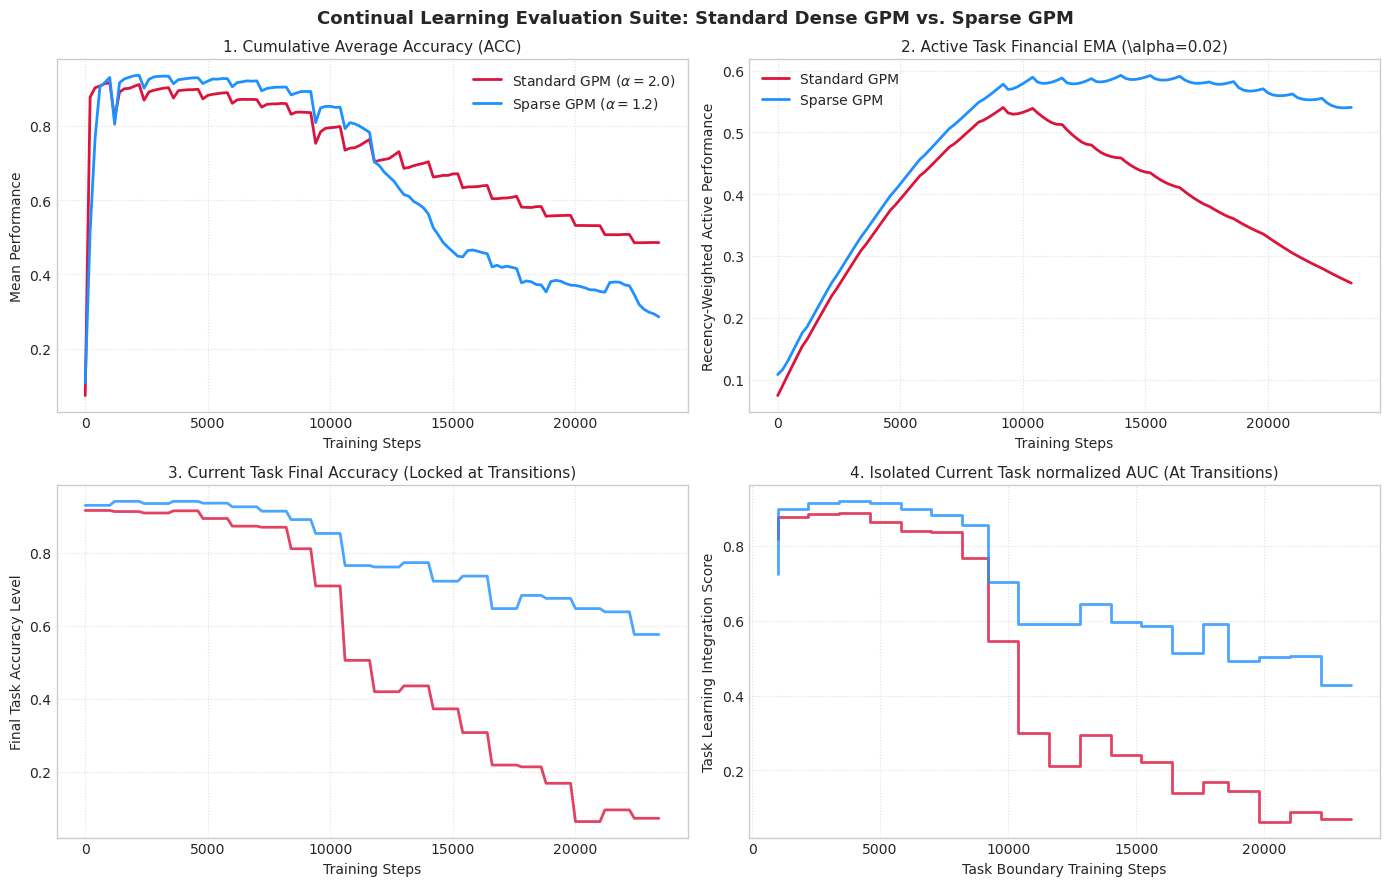

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. LOAD THE DATA ---
df_dense = pd.read_csv('gpm_alpha2_0.csv')
df_sparse = pd.read_csv('sparse_gpm_alpha1_2.csv')

def compute_cl_metrics(df, ema_alpha=0.01):
    steps = df['step'].values
    num_entries = len(df)

    # Extract only the task accuracy columns and sort them chronologically
    task_cols = [c for c in df.columns if c.startswith('task_') and c.endswith('_acc')]
    task_cols = sorted(task_cols, key=lambda x: int(x.split('_')[1]))
    acc_matrix = df[task_cols].values

    # 1. Standard Cumulative Average Accuracy (ACC)
    avg_acc_history = np.zeros(num_entries)
    for idx in range(num_entries):
        row = acc_matrix[idx, :]
        active_accs = row[~np.isnan(row)]
        if len(active_accs) > 0:
            avg_acc_history[idx] = np.mean(active_accs)

    # Track active tasks per step to accurately isolate boundaries
    active_tasks_per_step = np.array([df.iloc[idx][task_cols].notna().sum() for idx in range(num_entries)])

    # Find transition step indices (where task count increments or the final step)
    transition_indices = []
    current_num = active_tasks_per_step[0]
    for idx in range(1, num_entries):
        if active_tasks_per_step[idx] > current_num:
            transition_indices.append(idx - 1)  # Last step of the old task
            current_num = active_tasks_per_step[idx]
    transition_indices.append(num_entries - 1)  # Enforce final step boundary

    # -----------------------------------------------------------------
    # METRIC 2: TRUE INSTANTANEOUS FINANCIAL EMA
    # -----------------------------------------------------------------
    # Instead of smoothing the global average, we smooth the raw accuracy of the task actively being trained.
    ema_acc_history = np.zeros(num_entries)

    for idx in range(num_entries):
        active_task_idx = max(0, active_tasks_per_step[idx] - 1)
        instant_acc = acc_matrix[idx, active_task_idx]

        if np.isnan(instant_acc):
            instant_acc = avg_acc_history[idx]  # Fallback if entry is empty

        if idx == 0:
            ema_acc_history[idx] = instant_acc
        else:
            # Classic financial recurrence relation weighting recency over history
            ema_acc_history[idx] = (instant_acc * ema_alpha) + (ema_acc_history[idx - 1] * (1.0 - ema_alpha))

    # -----------------------------------------------------------------
    # METRICS 3 & 4: CURRENT TASK TRANSITION ACC & DISCRETE PLASTICITY AUC
    # -----------------------------------------------------------------
    current_task_transition_acc = np.zeros(num_entries)

    # Dictionary to hold the final AUC value indexed by the transition step
    discrete_auc_points = {}

    current_task_ptr = 0
    for idx in range(num_entries):
        active_task_count = active_tasks_per_step[idx]
        current_task_col_idx = max(0, active_task_count - 1)

        if current_task_ptr < len(transition_indices) - 1 and idx > transition_indices[current_task_ptr]:
            current_task_ptr += 1

        # Lock final accuracy at the transition step
        milestone_step_idx = transition_indices[current_task_ptr]
        current_task_transition_acc[idx] = acc_matrix[milestone_step_idx, current_task_col_idx]

    # Calculate AUC strictly at the end of each task's lifecycle window
    prev_boundary = 0
    for boundary_idx in transition_indices:
        # Determine which task just finished training at this boundary
        task_count_at_boundary = active_tasks_per_step[boundary_idx]
        task_col = max(0, task_count_at_boundary - 1)

        # Extract the vector of values spanning ONLY this task's active training run
        y_task = acc_matrix[prev_boundary:boundary_idx + 1, task_col]
        x_task = steps[prev_boundary:boundary_idx + 1]

        valid_mask = ~np.isnan(y_task)
        if np.sum(valid_mask) > 1:
            auc_val = np.trapz(y_task[valid_mask], x_task[valid_mask])
            max_auc = (x_task[valid_mask][-1] - x_task[valid_mask][0]) * 1.0
            norm_auc = auc_val / max_auc if max_auc > 0 else y_task[valid_mask][-1]
        else:
            norm_auc = 0.0

        # Store the computed scalar explicitly at the boundary step
        discrete_auc_points[steps[boundary_idx]] = norm_auc
        prev_boundary = boundary_idx + 1

    return steps, avg_acc_history, ema_acc_history, current_task_transition_acc, discrete_auc_points

# --- 2. COMPUTE METRICS FOR BOTH EXPERIMENTS ---
# A slightly higher alpha (e.g., 0.02 to 0.05) speeds up decay to highlight the crossover
alpha_financial = 0.02
steps_d, avg_d, ema_d, curr_d, auc_pts_d = compute_cl_metrics(df_dense, ema_alpha=alpha_financial)
steps_s, avg_s, ema_s, curr_s, auc_pts_s = compute_cl_metrics(df_sparse, ema_alpha=alpha_financial)

# --- 3. PLOTTING THE FOUR FIGURES ---
fig, axs = plt.subplots(2, 2, figsize=(14, 9), dpi=100)

# Figure 1: Average Accuracy (ACC)
axs[0, 0].plot(steps_d, avg_d, color='crimson', linewidth=2, label='Standard GPM ($\\alpha=2.0$)')
axs[0, 0].plot(steps_s, avg_s, color='dodgerblue', linewidth=2, label='Sparse GPM ($\\alpha=1.2$)')
axs[0, 0].set_title('1. Cumulative Average Accuracy (ACC)', fontsize=11)
axs[0, 0].set_xlabel('Training Steps')
axs[0, 0].set_ylabel('Mean Performance')
axs[0, 0].grid(True, linestyle=':', alpha=0.6)
axs[0, 0].legend()

# Figure 2: Real Instantaneous Financial EMA (Expected Overtake/Crossover)
axs[0, 1].plot(steps_d, ema_d, color='crimson', linewidth=2, label='Standard GPM')
axs[0, 1].plot(steps_s, ema_s, color='dodgerblue', linewidth=2, label='Sparse GPM')
axs[0, 1].set_title(f'2. Active Task Financial EMA (\\alpha={alpha_financial})', fontsize=11)
axs[0, 1].set_xlabel('Training Steps')
axs[0, 1].set_ylabel('Recency-Weighted Active Performance')
axs[0, 1].grid(True, linestyle=':', alpha=0.6)
axs[0, 1].legend()

# Figure 3: Current Task Accuracy Locked at Transitions
axs[1, 0].plot(steps_d, curr_d, color='crimson', linewidth=2, alpha=0.8)
axs[1, 0].plot(steps_s, curr_s, color='dodgerblue', linewidth=2, alpha=0.8)
axs[1, 0].set_title('3. Current Task Final Accuracy (Locked at Transitions)', fontsize=11)
axs[1, 0].set_xlabel('Training Steps')
axs[1, 0].set_ylabel('Final Task Accuracy Level')
axs[1, 0].grid(True, linestyle=':', alpha=0.6)

# Figure 4: Localized Current Task AUC (Plotted ONLY at Transition Ends)
# Connect them with a clean step line to easily trace the progression across tasks
axs[1, 1].step(list(auc_pts_d.keys()), list(auc_pts_d.values()), color='crimson', linewidth=2, alpha=0.8)
axs[1, 1].step(list(auc_pts_s.keys()), list(auc_pts_s.values()), color='dodgerblue', linewidth=2, alpha=0.8)

axs[1, 1].set_title('4. Isolated Current Task normalized AUC (At Transitions)', fontsize=11)
axs[1, 1].set_xlabel('Task Boundary Training Steps')
axs[1, 1].set_ylabel('Task Learning Integration Score')
axs[1, 1].grid(True, linestyle=':', alpha=0.6)
axs[1, 1].legend()

plt.suptitle('Continual Learning Evaluation Suite: Standard Dense GPM vs. Sparse GPM', fontsize=13, weight='bold')
plt.savefig("gpm_vs_sparsegpm.pdf", bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

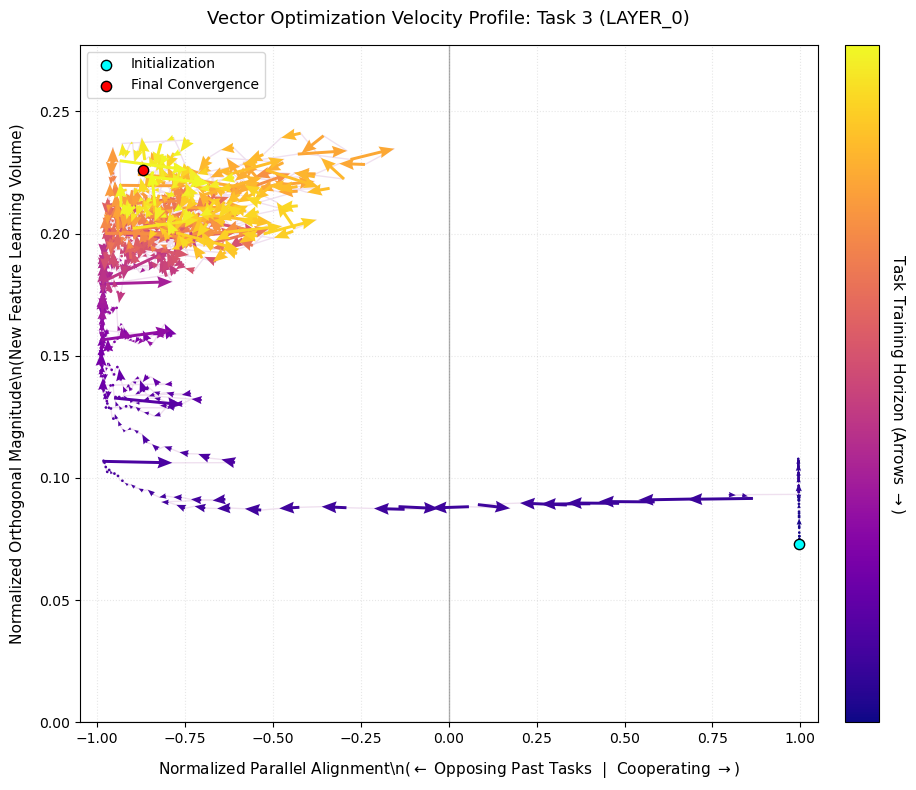

In [ ]:
%matplotlib inline

def plot_single_task_quiver(tracker, target_task_idx=2, target_layer='layer_0',
                            smoothing_alpha=0.1, arrow_stride=40):
    """
    Plots a static 2D phase portrait for a single task using quiver arrows,
    updated to fetch data from multi-layer dictionary metrics.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # 1. Map step boundaries for the targeted task block
    start_step_idx = 0 if target_task_idx == 0 else tracker.task_boundaries[target_task_idx - 1]
    end_step_idx = tracker.task_boundaries[target_task_idx]

    # 2. Isolate steps
    global_steps = np.array(tracker.steps)
    task_mask = (global_steps >= start_step_idx) & (global_steps < end_step_idx)
    sliced_steps = global_steps[task_mask]

    # 3. Safely extract vectors for the specified layer key
    if target_layer not in tracker.x_parallel_normalized:
        print(f"No tracking logs found for layer: {target_layer}")
        return

    x_raw = np.array(tracker.x_parallel_normalized[target_layer])[task_mask]
    y_raw = np.array(tracker.y_orthogonal_normalized[target_layer])[task_mask]

    if len(x_raw) == 0:
        print(f"No data points captured for {target_layer} during Task {target_task_idx + 1}.")
        return

    # 4. Smooth coordinates
    x_smoothed = pd.Series(x_raw).ewm(alpha=smoothing_alpha, adjust=False).mean().values
    y_smoothed = pd.Series(y_raw).ewm(alpha=smoothing_alpha, adjust=False).mean().values

    fig, ax = plt.subplots(figsize=(10, 8))

    # --- GEOMETRIC TRAILS ---
    ax.plot(x_smoothed, y_smoothed, color='purple', alpha=0.12, linewidth=1.0, zorder=1)

    dx = np.diff(x_smoothed)
    dy = np.diff(y_smoothed)
    quiver_indices = np.arange(0, len(dx), arrow_stride)

    x_pos = x_smoothed[quiver_indices]
    y_pos = y_smoothed[quiver_indices]
    u_dir = dx[quiver_indices]
    v_dir = dy[quiver_indices]

    colors = np.arange(len(quiver_indices))
    cmap = plt.get_cmap('plasma')

    quiver = ax.quiver(x_pos, y_pos, u_dir, v_dir, colors, cmap=cmap,
                       scale_units='xy', angles='xy', scale=1,
                       width=0.004, headwidth=4, headlength=5, zorder=3)

    cbar = fig.colorbar(quiver, ax=ax, pad=0.03)
    cbar.set_label(r'Task Training Horizon (Arrows $\rightarrow$)', fontsize=11, rotation=270, labelpad=20)
    cbar.set_ticks([])

    # System limits
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(0.00, max(y_smoothed) * 1.15)
    ax.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.3)
    ax.axvline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.3)
    ax.grid(True, linestyle=':', alpha=0.3)

    ax.set_xlabel(r'Normalized Parallel Alignment\n' + r'($\leftarrow$ Opposing Past Tasks  |  Cooperating $\rightarrow$)', fontsize=11, labelpad=10)
    ax.set_ylabel(r'Normalized Orthogonal Magnitude\n(New Feature Learning Volume)', fontsize=11, labelpad=10)
    ax.set_title(f'Vector Optimization Velocity Profile: Task {target_task_idx + 1} ({target_layer.upper()})', fontsize=13, pad=15)

    ax.scatter(x_smoothed[0], y_smoothed[0], color='cyan', edgecolor='black', s=55, zorder=5, label='Initialization')
    ax.scatter(x_smoothed[-1], y_smoothed[-1], color='red', edgecolor='black', s=55, zorder=5, label='Final Convergence')
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_single_task_quiver(align_tracker, target_task_idx=4, target_layer='layer_0', arrow_stride=2)

In [ ]:
# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TASKS = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
LR = 1e-2
GAMMA = 0.001
K_STEEPNESS = 3000.0
BATCH_SIZE = 64 # Increased for GPU efficiency
EPOCHS_PER_TASK = 10

class EbbinghausOptimizer:
    def __init__(self, model, lr=LR, gamma=GAMMA, k_max=K_STEEPNESS, k_min=10):
        self.params = [p for p in model.parameters() if p.requires_grad]
        self.lr = lr
        self.gamma = gamma
        self.k_max = k_max
        self.k_min = k_min
        self.k_layers = []
        for i in range(len(self.params)):
            # Linear example:
            ratio = i / (len(self.params) - 1)
            k_val = self.k_max - ratio * (self.k_max - self.k_min)
            self.k_layers.append(k_val)
        # Stability accumulator S_i
        self.stability = [torch.zeros_like(p, device=DEVICE) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None: continue

                # 1. Dynamic Decay (Standard)
                # We can stick to a simpler decay here since the growth is self-regulating
                self.stability[i] = (1.0 - self.gamma) * self.stability[i]

                # 2. Saturating Growth (Diminishing Returns)
                # The 'fuller' the memory, the harder it is to add more.
                grad_sq = p.grad ** 2
                growth_resistance = 1.0 + self.stability[i]
                self.stability[i] += grad_sq / growth_resistance

                # 3. Calculate Hyperbolic Plasticity Filter
                plasticity = 1.0 / (1.0 + self.k_layers[i] * self.stability[i])

                # 4. Apply Filtered Update
                p.data -= self.lr * plasticity * p.grad

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_()
                p.grad.zero_()

# --- 2. Training Loop ---
model = SimpleMLP().to(DEVICE)
ebbinghaus_opt = EbbinghausOptimizer(model)
criterion = nn.CrossEntropyLoss()
tracker = MetricsTracker()
total_steps = 0

(train_x, train_y), (test_x, test_y) = get_gpu_mnist()
all_test_tasks = [get_task_data(test_x, test_y, t) for t in TASKS]
results_matrix = []

for t_idx, digits in enumerate(TASKS):
    tx, ty = get_task_data(train_x, train_y, digits)
    print(f"Training Task {t_idx} (Digits {digits})")

    for epoch in range(EPOCHS_PER_TASK):
        indices = torch.randperm(len(tx))
        for i in range(0, len(tx), BATCH_SIZE):
            batch_idx = indices[i:i+BATCH_SIZE]
            bx, by = tx[batch_idx], ty[batch_idx]

            ebbinghaus_opt.zero_grad()
            output = model(bx)
            loss = criterion(output, by)
            loss.backward()

            # This is where the magic happens: No penalty, just a filtered step
            ebbinghaus_opt.step()

            total_steps += 1

            # High-Resolution Intra-Task Tracking
            if total_steps % EVAL_EVERY_N_BATCHES == 0:
                current_accs = evaluate(model, all_test_tasks)
                tracker.log(total_steps, current_accs, loss.item(), ebbinghaus_opt.stability)

        current_accs = evaluate(model, all_test_tasks)
        print(f"Epoch {epoch} Accuracies: {[round(a, 2) for a in current_accs]}")

    results_matrix.append(current_accs)

Training Task 0 (Digits [0, 1])
Epoch 0 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 1 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 2 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 3 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 4 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 5 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 6 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 7 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 8 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 9 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Training Task 1 (Digits [2, 3])
Epoch 0 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 1 Accuracies: [1.0, 0.24, 0.0, 0.0, 0.0]
Epoch 2 Accuracies: [0.99, 0.72, 0.0, 0.0, 0.0]
Epoch 3 Accuracies: [0.97, 0.88, 0.0, 0.0, 0.0]
Epoch 4 Accuracies: [0.92, 0.92, 0.0, 0.0, 0.0]
Epoch 5 Accuracies: [0.82, 0.94, 0.0, 0.0, 0.0]
Epoch 6 Accuracies: [0.57, 0.94, 0.0, 0.0, 0.0]
Epoch 7 Accuracies: [0.31, 0.95, 0.0, 0.0, 0.0]
Epoch 8 Accuracies: [0.23, 0.95, 0.0, 0.0, 0.0]
Epoch 9 Accuracies: [0.19, 0.95, 0.0, 0.0, 0.0]

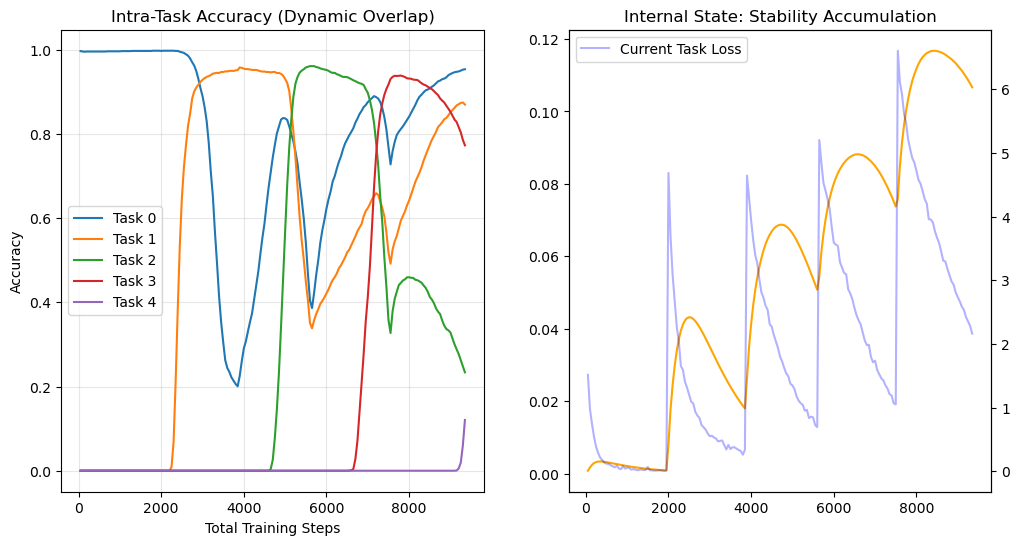

In [ ]:
def plot_research_results(tracker):
    steps = tracker.history['steps']
    accs = np.array(tracker.history['accuracies'])

    plt.figure(figsize=(12, 6))

    # 1. Learning Curves (All Tasks)
    plt.subplot(1, 2, 1)
    for i in range(len(TASKS)):
        plt.plot(steps, accs[:, i], label=f'Task {i}')

    # Draw vertical lines for task boundaries
    steps_per_task = (len(train_x)//len(TASKS)//BATCH_SIZE) * EPOCHS_PER_TASK
    # (Note: This is an approximation; calculate exactly based on your split sizes)

    plt.title("Intra-Task Accuracy (Dynamic Overlap)")
    plt.xlabel("Total Training Steps")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    # 2. Stability Growth vs. Loss
    plt.subplot(1, 2, 2)
    plt.plot(steps, tracker.history['stability_means'], label='Mean Stability (S)', color='orange')
    plt.twinx()
    plt.plot(steps, tracker.history['losses'], label='Current Task Loss', color='blue', alpha=0.3)
    plt.title("Internal State: Stability Accumulation")
    plt.xlabel("Total Training Steps")
    plt.legend()
    plt.show()

plot_research_results(tracker)